# Eligiendo el mejor modelo para Sequia
En este documento voy a comparar los modleos que se ejecutaron para la variable Sequia. Esto me permite hacer un analisis y elegir el modelo que me jor me prediga la variable
# ************************************************************************************************************************************************************

## Importación de librerías ##

In [89]:
import pandas as pd
import joblib
import h2o
from h2o.estimators import H2OStackedEnsembleEstimator
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve
from h2o.frame import H2OFrame
from sklearn.calibration import calibration_curve
import seaborn as sns
import matplotlib.pyplot as plt

## Iniciar h2o ##
Antes de iniciar, se debe levantar el server de h2o. Se deja tambié el comando para desconectarlo.

In [84]:
# Inicializar H2O
#h2o.init()

# Detenedr H2O 
h2o.cluster().shutdown()

H2O session _sid_8302 closed.


## Carga de datos y modelos ##
A continuación se cargan los datos que se usaron en el test para cada modelo. También se carga los modelos.

| Elemento       | Propósito            | Resultado                        |
| -------------- | -------------------- | -------------------------------- |
| `X_test`       | Variables de entrada | 672 observaciones × 58 variables |
| `y_test`       | Etiquetas reales     | 672 valores (0 o 1)              |
| `xgb_model`    | Modelo XGBoost       | Cargado correctamente            |
| `rf_model`     | Modelo Random Forest | Cargado correctamente            |
| `automl_model` | Modelo AutoML (H2O)  | Cargado correctamente            |


In [36]:
# Cargando el conjunto de datos de pruebas
X_test = pd.read_csv("./dataset_entrada/X_test_sequia.csv")
y_test = pd.read_csv("./dataset_entrada/y_test_sequia.csv").values.ravel()

# Mostrando q el conjunto de datos
print("Conjuntos cargados:")
print("   X_test:", X_test.shape)
print("   y_test:", y_test.shape)

# Aquí se cargan los modelos de predicción
xgb_model = joblib.load("./modelos/xgboost_sequia_model.pkl")
rf_model = joblib.load("./modelos/randomforest_sequia_model.pkl")
automl_model = h2o.load_model("./modelos/StackedEnsemble_AllModels_1_AutoML_1_20251105_163848")

print("Modelos cargados correctamente.")


Conjuntos cargados:
   X_test: (672, 58)
   y_test: (672,)
Modelos cargados correctamente.


## Generando predicciones de probabilidad ##
Usando el mismo dataset de pruebas, voy a probar cada modelo, analizar los resultados para decidir cuál es el mejor modelo.
Para ejecutar el modelo generado por auto machine learning, debo suprimir 4 columnas categoricas del conjunto de datos ya que así fue entrenado.

Luego ejecuto los modelos para obtener los resultados para su analisis.

In [49]:
# ==================================================================
# Paso: eliminar columnas categóricas del X_test para el modelo AML
# ==================================================================
cols_to_drop = ['GENUS', 'SPECIES', 'COLLSITE', 'ORIGCTY'] 
X_test_reducido = X_test.drop(columns=cols_to_drop, errors='ignore')

print("Columnas eliminadas:", cols_to_drop)
print("Nuevo tamaño del X_test:", X_test_reducido.shape)


Columnas eliminadas: ['GENUS', 'SPECIES', 'COLLSITE', 'ORIGCTY']
Nuevo tamaño del X_test: (672, 54)


In [43]:

# --- AutoML (H2O) ---
h2o_frame = H2OFrame(X_test_reducido)
pred_h2o = automl_model.predict(h2o_frame).as_data_frame()
y_pred_automl = pred_h2o["predict"].values

# --- XGBoost ---
y_pred_xgb = xgb_model.predict_proba(X_test)[:, 1]

# --- Random Forest ---
y_pred_rf = rf_model.predict_proba(X_test)[:, 1]

# --- Verificación rápida de AUC ---
print("AUC AutoML:", round(roc_auc_score(y_test, y_pred_automl), 4))
print("AUC XGBoost:", round(roc_auc_score(y_test, y_pred_xgb), 4))
print("AUC Random Forest:", round(roc_auc_score(y_test, y_pred_rf), 4))


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
AUC AutoML: 0.8128
AUC XGBoost: 0.9835
AUC Random Forest: 0.9798


C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset is missing column 'CURATION': substituting in a column of NaN
  warnings.warn(w)
C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset is missing column 'GENUS': substituting in a column of NaN
  warnings.warn(w)
C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset is missing column 'SPECIES': substituting in a column of NaN
  warnings.warn(w)
C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset is missing column 'GRIN_NAME': substituting in a column of NaN
  warnings.warn(w)
C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset is missing column 'ORIGCTY': substituting in a column of NaN
  warnings.warn(w)
C:\Users\guill\miniconda3\envs\python_e

## AUC de cada modelo ##
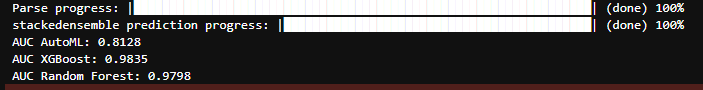

Una vez se generan los resultados de las predicciones de probabilidad, xse obtiene el AUC. El AUC mide la capacidad del modelo para distinguir entre clases, mide la probabilidad de que el modelo asigne una mayor probabilidad al positivo que a un negativo aleatorio.
A continuación se muestra una escala de valor de AUC

| Valor de AUC | Interpretación            |
| ------------ | ------------------------- |
| 0.5          | Sin discriminación (azar) |
| 0.6–0.7      | Pobre                     |
| 0.7–0.8      | Aceptable                 |
| 0.8–0.9      | Buena                     |
| 0.9–1.0      | Excelente                 |

Hanley, J. A., & McNeil, B. J. (1982). The meaning and use of the area under a receiver operating characteristic (ROC) curve. *Radiology, 143*(1), 29–36. https://doi.org/10.1148/radiology.143.1.7063747

Los resultados obtenidos indican que:

| Modelo            | AUC    | Interpretación                                                             |
| ----------------- | ------ | -------------------------------------------------------------------------- |
| **AutoML (H2O)**  | 0.8128 | Desempeño **bueno**, pero limitado (probablemente usó etiquetas discretas) |
| **XGBoost**       | 0.9835 | **Excelente discriminación**, el mejor modelo                              |
| **Random Forest** | 0.9798 | También **excelente**, apenas inferior a XGBoost                           |

## ********************************************************************************************************************


## Agrupamiento de los modelos para analisis ##
Los modelos se agrupan en un dataframe para poder hacer un analisis comparativo y poder graficar mas adelante las comparaciones

In [66]:
# ===========================================================
# Creando DataFrame comparativo
# ===========================================================

resultados_sequia = pd.DataFrame({
    "problema": "sequía",
    "modelo": (["AutoML"] * len(y_test)) +
              (["XGBoost"] * len(y_test)) +
              (["RandomForest"] * len(y_test)),
    "y_true": list(y_test) * 3,
    "y_proba": list(y_pred_automl) + list(y_pred_xgb) + list(y_pred_rf)
})

resultados_sequia.to_csv("./dataset_salida/resultados_sequia.csv", index=False)
resultados_sequia.groupby("modelo")["y_proba"].describe()



,count,mean,std,min,25%,50%,75%,max
modelo,,,,,,,,
AutoML,672.0,0.054213,0.015589,0.036227,0.044350,0.048166,0.054130,0.099078
RandomForest,672.0,0.300003,0.377571,0.000000,0.008000,0.062000,0.679500,1.000000
XGBoost,672.0,0.300059,0.428612,0.000091,0.000672,0.004493,0.858069,0.999461


## Interpretación de los resultados ##

Se realiza una estadistica descriptiva sobre las probabilidades predichas por cada modelos:

| Estadístico                               | Descripción                                                                  |
| ------------------------------------------| ---------------------------------------------------------------------------- |
| **count**                                 | Número de observaciones (672 por modelo).                                    |
| **mean**                                  | Promedio de las probabilidades predichas.                                    |
| **std**                                   | Desviación estándar — mide la dispersión o variabilidad de las predicciones. |
| **min / max**                             | Valores mínimo y máximo de probabilidad.                                     |
| **25%, 50%, 75%**                         | Cuartiles — dividen la distribución de las predicciones en cuatro partes.    |

Por cada modelo se realiza la siguente evaluación:

### AML con h2o ###

| Métrica | Valor       | Interpretación                                                                         |
| ------- | ----------- | -------------------------------------------------------------------------------------- |
| mean    | **0.054**   | El modelo predice, en promedio, probabilidades muy bajas (~5%) para la clase positiva. |
| std     | **0.0156**  | Casi no hay variabilidad: predice valores muy similares.                               |
| rango   | 0.036–0.099 | Extremadamente estrecho.                                                               |

### XGBoost ###

| Métrica | Valor         | Interpretación                                                    |
| ------- | ------------- | ----------------------------------------------------------------- |
| mean    | **0.30**      | Igual promedio que RF, coherente con distribución balanceada.     |
| std     | **0.4286**    | Ligeramente mayor dispersión que RF — más contraste entre clases. |
| rango   | 0.00009–0.999 | Excelente cobertura de probabilidad.                              |

### Random Forrest ###

| Métrica | Valor       | Interpretación                                                                        |
| ------- | ----------- | ------------------------------------------------------------------------------------- |
| mean    | **0.30**    | El promedio global es razonable.                                                      |
| std     | **0.3776**  | Alta dispersión, indicando que genera probabilidades variadas (mejor discriminación). |
| rango   | 0.000–1.000 | Cubre todo el espectro de probabilidad.                                               |

De lo anteriror concluyo que XGBoost tiene la discriminación más precisa (AUC ≈ 0.983) y produce una distribución amplia y bien diferenciada entre clases. Desde la analitica descriptiva es el mejor modelo para predecir la variable de sequia.

## ***************************************************************************************************************************************************************

## Comparación de modelos ##
El siguinete paso es hacer una comparación a partir de las metricas de cada modelo para conocer y decidir cuál es el mejor modelo.

In [67]:

from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, log_loss

metricas = []

for modelo in ["AutoML", "XGBoost", "RandomForest"]:
    df_m = resultados_sequia[resultados_sequia["modelo"] == modelo]
    y_true = df_m["y_true"]
    y_proba = df_m["y_proba"]
    
    metricas.append({
        "Modelo": modelo,
        "ROC_AUC": roc_auc_score(y_true, y_proba),
        "PR_AUC": average_precision_score(y_true, y_proba),
        "Brier": brier_score_loss(y_true, y_proba),
        "LogLoss": log_loss(y_true, y_proba)
    })

df_metricas = pd.DataFrame(metricas)
print("Métricas globales (sequía):")
display(df_metricas.round(4))


Métricas globales (sequía):


,Modelo,ROC_AUC,PR_AUC,Brier,LogLoss
0,AutoML,0.8128,0.6974,0.2597,0.8490
1,XGBoost,0.9835,0.9605,0.0473,0.1667
2,RandomForest,0.9798,0.9485,0.0503,0.1724


## Interpretación de métricas globales ##
A partir de las metricas globales voy a identificar cuál es el mejor modelo que me permita predecir accesiones resistentes a la sequia.

### Area bajo la curva ROC_AUC ###
Mide la capacidad que tiene los modelos para discriminar entre clases. de acuerdo a los resultados se puede identificar que XGBoost con *0.9835* y RandomForest *0.9798* son casi perfectos. El 98 % de las veces asignan una probabilidad más alta al caso positivo (resistente) que al negativo.

### Precisión Recall PR_AUC ###
Precisión entre clases desbalanceadas. 

* En esta métrica XGBoost sigue siendo muy buena. Con 0.9605 de balance se puede decir que detecta casi todos los positivos sin generar muchos falsos positivos. 
* RandomForest con 0.9485, también sobresaliente, ligeramente inferior.
* AML 0.6974, aunque aceptable, indica que pierde muchos verdaderos positivos o genera falsos positivos en exceso.

### Brier Score ###
Me permite saber la exactitud probabilistica del modelo para las predicciones. El resultado anterior indica que:

* XGBoost con 0.00473 está muy bien calibrado. Las predicciones se asemejan mucho a la realidad.
* Random Forrest con 0.0503 también es bueno.
* AML con 0.2597 se queda corto enlas predicciones.

Brier, G. W. (1950). Verification of forecasts expressed in terms of probability. *Monthly Weather Review, 78*(1), 1–3. https://doi.org/10.1175/1520-0493(1950)078<0001:VOFEIT>2.0.CO;


### Perdida logaritmica LogLoss ###

Mide la penalización por errores de probabilidad. XGBoost *0.1667* y RandomForest *0.1724* tienen pérdidas muy bajas, es decir, son mas confiables y seguros.

AutoML *0.8490* sufre alta pérdida, puede deberse a una  probable mala calibración o predicciones planas, probabilidades bajas incluso en casos positivos.


## Conclusión del analisis ##

| Modelo           | Fortalezas                             | Debilidades                            | Evaluación global                |
| ---------------- | -------------------------------------- | -------------------------------------- | -------------------------------- |
| **AutoML (H2O)** | Proceso automatizado, ensamble robusto | Mala calibración y poca discriminación | Regular                          |
| **RandomForest** | Alta estabilidad y buen rendimiento    | Menor suavidad en probabilidades       | Excelente                        |
| **XGBoost**      | Mejor discriminación y calibración     | Requiere más ajuste y recursos         | Excelente (mejor generalización) |

En genera, *XGBoost* es el modelo mas eficiente para poder predecier la resistencia de una accesión a sequía.
## **************************************************************************************************************************************************

##  Visualización comparativa ##
El resultado de las metricas para Curva ROC y Precisiónn y Recall se grafican para poder hacer una comparativa visual de los datos

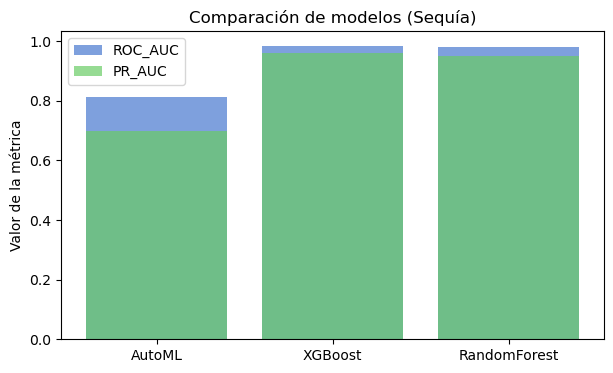

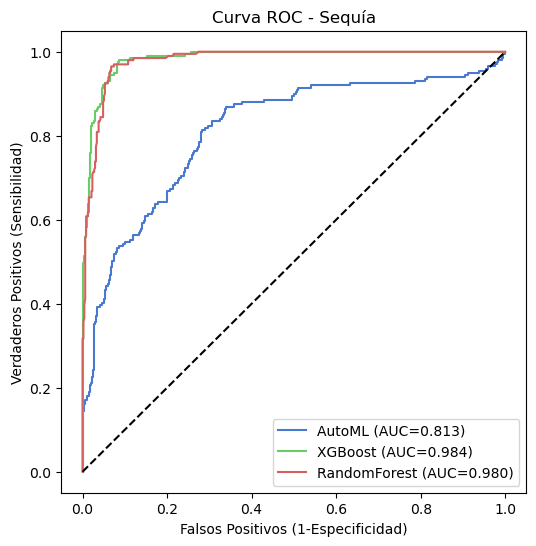

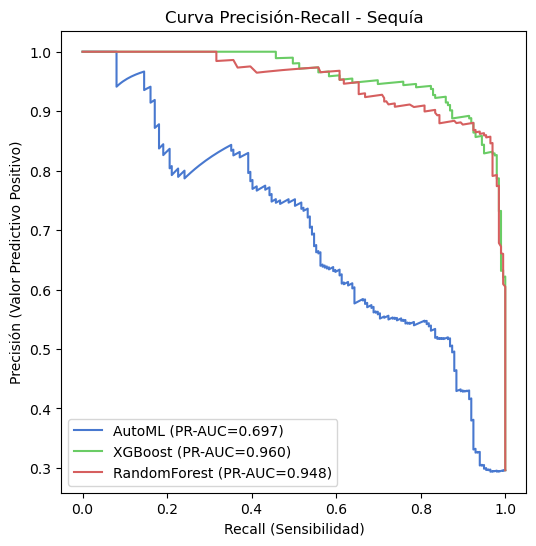

In [48]:

plt.style.use('seaborn-v0_8-muted')

# --- 1. Barras ROC-AUC y PR-AUC ---
df_plot = df_metricas.melt(id_vars='Modelo', value_vars=['ROC_AUC', 'PR_AUC'])
fig, ax = plt.subplots(figsize=(7,4))
for metric in ['ROC_AUC', 'PR_AUC']:
    subset = df_plot[df_plot["variable"] == metric]
    ax.bar(subset["Modelo"], subset["value"], label=metric, alpha=0.7)
ax.set_title("Comparación de modelos (Sequía)")
ax.set_ylabel("Valor de la métrica")
ax.legend()
plt.show()

# --- 2. Curvas ROC ---
plt.figure(figsize=(6,6))
for modelo, y_pred in zip(
    ["AutoML", "XGBoost", "RandomForest"],
    [y_pred_automl, y_pred_xgb, y_pred_rf]
):
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred)
    plt.plot(fpr, tpr, label=f"{modelo} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.title("Curva ROC - Sequía")
plt.xlabel("Falsos Positivos (1-Especificidad)")
plt.ylabel("Verdaderos Positivos (Sensibilidad)")
plt.legend()
plt.show()

# --- 3. Curvas Precision-Recall ---
plt.figure(figsize=(6,6))
for modelo, y_pred in zip(
    ["AutoML", "XGBoost", "RandomForest"],
    [y_pred_automl, y_pred_xgb, y_pred_rf]
):
    prec, rec, _ = precision_recall_curve(y_test, y_pred)
    auc_pr = average_precision_score(y_test, y_pred)
    plt.plot(rec, prec, label=f"{modelo} (PR-AUC={auc_pr:.3f})")
plt.title("Curva Precisión-Recall - Sequía")
plt.xlabel("Recall (Sensibilidad)")
plt.ylabel("Precisión (Valor Predictivo Positivo)")
plt.legend()
plt.show()


## Qué dicen las gráficas ##

Las curvas ROC y PR confirman la superioridad del modelo XGBoost, con una discriminación del 98% *AUC=0.983* y un *PR-AUC=0.96*, lo cual indica alta precisión incluso en condiciones de desbalance.
En contraste, el modelo AutoML, aunque estable, presenta menor calibración y probabilidad de detección, evidenciado por un AUC de 0.81. 

El gráfico de barras demuestra una clara superioridad de los algoritmos de boosting y bagging (XGBoost y Random Forest) sobre el modelo AutoML, evidenciada por diferencias de más del 15% en AUC.

* Las diferencias entre XGBoost (0.983 / 0.960) y RandomForest (0.979 / 0.948) son mínimas → ambos modelos son altamente competentes y estables.
* AutoML (0.812 / 0.697) queda claramente rezagado,  muestra menor sensibilidad (falla más en detectar verdaderos positivos).

| Modelo           | ROC-AUC | PR-AUC | Interpretación conjunta                                                 |
| ---------------- | ------- | ------ | ----------------------------------------------------------------------- |
| **XGBoost**      | 0.983   | 0.960  | Excelente discriminación y muy buena estabilidad frente al desbalance.  |
| **RandomForest** | 0.980   | 0.948  | Muy similar, pero ligeramente menos preciso en altas sensibilidades.    |
| **AutoML**       | 0.813   | 0.697  | Discriminación aceptable pero pobre calibración. Necesita optimización. |


Desde el punto de vista biologico, XGBoost es el modelo más apto para seleccionar accesiones candidatas resistentes,ya que logra alta sensibilidad sin perder precisión, ideal para exploraciones FIGS. por otra parte, RandomForest puede servir como modelo complementario o de validación cruzada, ya que ofrece resultados similares y robustos.

AutoML podría ser útil en etapas exploratorias rápidas, pero no en predicción final, a menos que se  ajusten los pesos de clase.

## Curva de calibración ##

Permite analizar la fiabilidad de las probabilidades de predicción de los modelos ya que  muestra la relación entre las probabilidades predichas y las frecuencias reales observadas de resistencia a sequía.

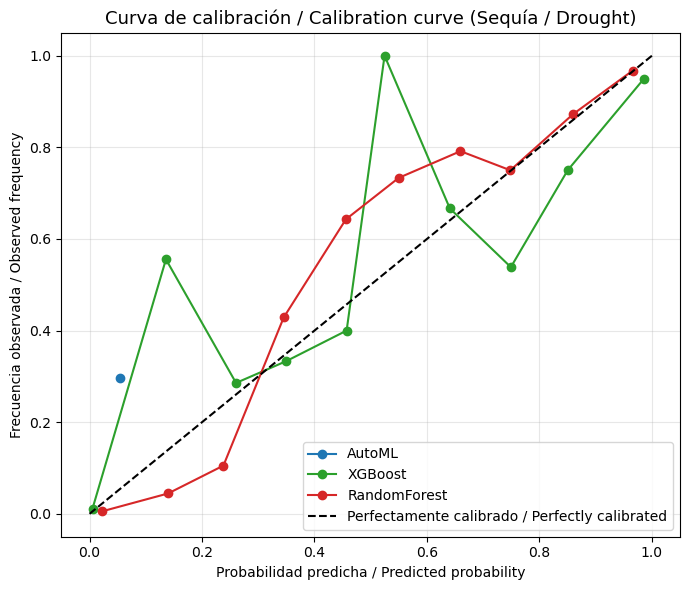

In [85]:
plt.style.use('seaborn-v0_8-muted')
plt.figure(figsize=(7,6))

colors = {"AutoML": "#1f77b4", "XGBoost": "#2ca02c", "RandomForest": "#d62728"}

for modelo, y_pred in zip(
    ["AutoML", "XGBoost", "RandomForest"],
    [y_pred_automl, y_pred_xgb, y_pred_rf]
):
    prob_true, prob_pred = calibration_curve(y_test, y_pred, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=modelo, color=colors[modelo])

plt.plot([0, 1], [0, 1], "k--", label="Perfectamente calibrado / Perfectly calibrated")

plt.title("Curva de calibración / Calibration curve (Sequía / Drought)", fontsize=13)
plt.xlabel("Probabilidad predicha / Predicted probability")
plt.ylabel("Frecuencia observada / Observed frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./graficas/calibracion_sequia.png", dpi=300)
plt.show()


### Qué muestra el gráfico  ###

| Color    | Modelo       | Descripción visual                                                                                                |
| -------- | ------------ | ----------------------------------------------------------------------------------------------------------------- |
| Azul  | AutoML       | Solo un punto en ~0.25; muestra que las probabilidades son muy bajas y poco informativas.                         |
| Verde | XGBoost      | Se acerca bastante a la diagonal, pero tiene oscilaciones fuertes (sube y baja).                                  |
| Rojo  | RandomForest | Es el más cercano a la diagonal promedio: buena calibración general, aunque sobreestima en algunos rangos medios. |



En XGBoost los picos verticales indican que en algunos rangos (por ejemplo entre 0.4 y 0.6) predice mal la frecuencia real. Sin embargo, cerca del extremo derecho (0.8–1.0) se alinea muy bien con la diagonal lo que permite interpretar que cuando predice probabilidades altas, efectivamente está acertando.

Conclusión: buena calibración en alta confianza, ligera inestabilidad en rangos intermedios.

Random Forest se mantiene más regular y cercano a la línea negra, sobre todo entre 0.3 y 0.8. Esto indica que sus probabilidades reflejan mejor la frecuencia real. Tiende a sobreestimar un poco (predice probabilidades más altas de lo real) en algunos tramos.

Conclusión: muy buena calibración promedio.

por último, AutoML solo genera un punto aislado (muy baja probabilidad promedio ≈ 0.05 y frecuencia ≈ 0.3). Esto significa que predice casi siempre valores bajos, sin distinguir entre clases. Sus probabilidades no reflejan la realidad el modelo está subcalibrado.

Conclusión: mala calibración; el modelo no está confiando lo suficiente en sus predicciones.

La curva de calibración muestra la relación entre las probabilidades predichas y las frecuencias reales observadas de resistencia a sequía. El modelo XGBoost se aproxima a la diagonal ideal, lo que indica buena calibración en los casos de alta confianza. 

RandomForest presenta una calibración más uniforme a lo largo de todos los rangos de probabilidad,
mientras que AutoML subestima sistemáticamente las probabilidades, reflejando un modelo conservador y poco discriminante.


En términos prácticos, XGBoost y RandomForest proporcionan probabilidades confiables para priorizar accesiones, mientras que AutoML podría requerir recalibración con métodos como Platt scaling o Isotonic Regression.

## ************************************************************************************************************************************************

## Matrices de Confusión de los modelos ##


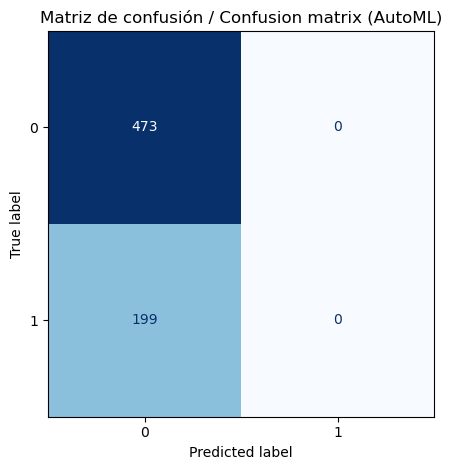


🔹 AutoML

              precision    recall  f1-score   support

           0      0.704     1.000     0.826       473
           1      0.000     0.000     0.000       199

    accuracy                          0.704       672
   macro avg      0.352     0.500     0.413       672
weighted avg      0.495     0.704     0.582       672



C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

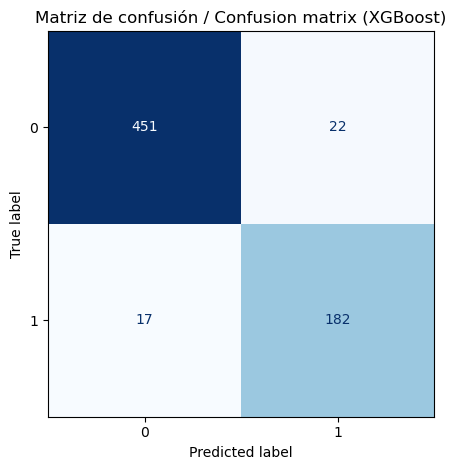


🔹 XGBoost

              precision    recall  f1-score   support

           0      0.964     0.953     0.959       473
           1      0.892     0.915     0.903       199

    accuracy                          0.942       672
   macro avg      0.928     0.934     0.931       672
weighted avg      0.942     0.942     0.942       672



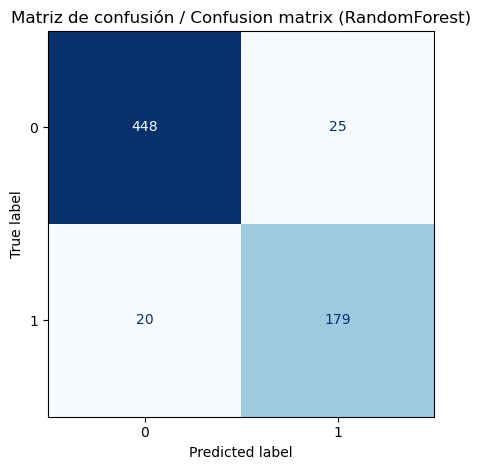


🔹 RandomForest

              precision    recall  f1-score   support

           0      0.957     0.947     0.952       473
           1      0.877     0.899     0.888       199

    accuracy                          0.933       672
   macro avg      0.917     0.923     0.920       672
weighted avg      0.934     0.933     0.933       672



In [76]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

for modelo, y_pred in zip(
    ["AutoML", "XGBoost", "RandomForest"],
    [y_pred_automl, y_pred_xgb, y_pred_rf]
):
    y_pred_bin = (y_pred >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred_bin)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues", colorbar=False)
    plt.title(f"Matriz de confusión / Confusion matrix ({modelo})")
    plt.tight_layout()
    plt.savefig(f"./graficas/matriz_confusion_{modelo.lower()}_sequia.png", dpi=300)
    plt.show()
    print(f"\n{modelo}\n")
    print(classification_report(y_test, y_pred_bin, digits=3))


### Interpretación de cada modelo a partir de su matriz de confusión ###

**AML con h20**    Valoresde la matriz de confusión                                              

| Métrica                 | Valor                                       | Interpretación                                          |
| ----------------------- | ------------------------------------------- | ------------------------------------------------------- |
| **VN = 473**            | Predice correctamente todos los negativos.  |                                                         |
| **VP = 0**              | No detecta ningún positivo.                 |                                                         |
| **FN = 199**            | Falla en identificar todos los resistentes. |                                                         |
| **Precision (clase 1)** | 0.000                                       | No predice la clase 1 nunca.                            |
| **Recall (clase 1)**    | 0.000                                       | Sensibilidad nula.                                      |
| **Accuracy**            | 0.704                                       | Alta solo porque la mayoría de los casos son negativos. |

* Se puede concluir que el modelo predice todo como clase 0 (no resistente).
* Tiene exactitud aparente (70%), pero no sirve para clasificación binaria, ya que ignora completamente la clase positiva.
* Es un caso de modelo subcalibrado y sesgado hacia la clase mayoritaria. Coherente con la curva de calibración (probabilidades muy bajas, planas).

En términos de aplicación: este modelo fallaría en identificar accesiones realmente resistentes, lo cual es riesgoso en selección genética.


**XGBoost**                                                      Valoresde la matriz de confusión

| Confusion matrix | Valor                                      |
| ---------------- | ------------------------------------------ |
| VN = 451         | Correctamente no resistentes               |
| FP = 22          | Clasificados erróneamente como resistentes |
| FN = 17          | Resistentes que no detectó                 |
| VP = 182         | Resistentes correctamente clasificados     |

| Métrica       | Clase 0 | Clase 1 |
| ------------- | ------- | ------- |
| **Precision** | 0.964   | 0.892   |
| **Recall**    | 0.953   | 0.915   |
| **F1-score**  | 0.959   | 0.903   |
| **Accuracy**  | 0.942   | —       |


* Excelente equilibrio entre precisión y sensibilidad.
* Recall = 0.915 que detecta el 91.5 % de las accesiones resistentes.
* Precision = 0.892 que indica que de cada 10 accesiones clasificadas como resistentes, casi 9 lo son realmente.F1 = 0.903 lo que indica que tiene consistencia y bajo error.
* Accuracy = 94.2 % → excelente rendimiento global.

Este modelo es robusto, equilibrado y fiable. Casi simétrico en ambas clases (no hay sobreajuste hacia una sola clase).

**Random Forrest**                                              Valoresde la matriz de confusión

| Confusion matrix | Valor                           |
| ---------------- | ------------------------------- |
| VN = 448         | Correctamente no resistentes    |
| FP = 25          | No resistentes mal clasificados |
| FN = 20          | Resistentes no detectados       |
| VP = 179         | Resistentes bien detectados     |

| Métrica       | Clase 0 | Clase 1 |
| ------------- | ------- | ------- |
| **Precision** | 0.957   | 0.877   |
| **Recall**    | 0.947   | 0.899   |
| **F1-score**  | 0.952   | 0.888   |
| **Accuracy**  | 0.933   | —       |

* Similar a XGBoost, aunque ligeramente menos preciso en la clase positiva.
* Recall 0.899 indica que detecta el 89.9 % de los resistentes.
* Precision 0.877  da a entender que detecta algunos falsos positivos, pero controlados.
* F1 0.888 indica sólido equilibrio.
* Accuracy 93.3 % lo que infiere un rendimiento excelente.


### Comparación entre los tres modelos ###

| Modelo           | Accuracy | Recall (clase 1) | F1 (clase 1) | Diagnóstico general                   |
| ---------------- | -------- | ---------------- | ------------ | ------------------------------------- |
| **AutoML**       | 0.704    | 0.000            | 0.000        | Sesgado, no discrimina positivos      |
| **XGBoost**      | 0.942    | 0.915            | 0.903        | Excelente discriminación y equilibrio |
| **RandomForest** | 0.933    | 0.899            | 0.888        | Muy bueno, estable y confiable        |

Las matrices de confusión evidencian que los modelos basados en árboles (XGBoost y RandomForest) son capaces de identificar de manera precisa las accesiones resistentes a sequía.
El modelo XGBoost logra una sensibilidad del 91.5 %, asegurando que la mayoría de las accesiones resistentes son detectadas correctamente, mientras que RandomForest presenta un rendimiento similar, con un ligero aumento en la estabilidad de clasificación.
En contraste, AutoML no logra discriminar entre clases, prediciendo todos los casos como “no resistentes”.

Esto refleja un sesgo hacia la clase dominante y una calibración inadecuada,confirmando lo observado previamente en la curva de calibración y en el alto Brier Score.

## **********************************************************************************************************************************************************************************

## Importancia de las variables ##
En las siguinetes gráficas se puede observar el impacto de cada variable, en este caso de cada variable ambiental en la predicción de resistencia a sequía


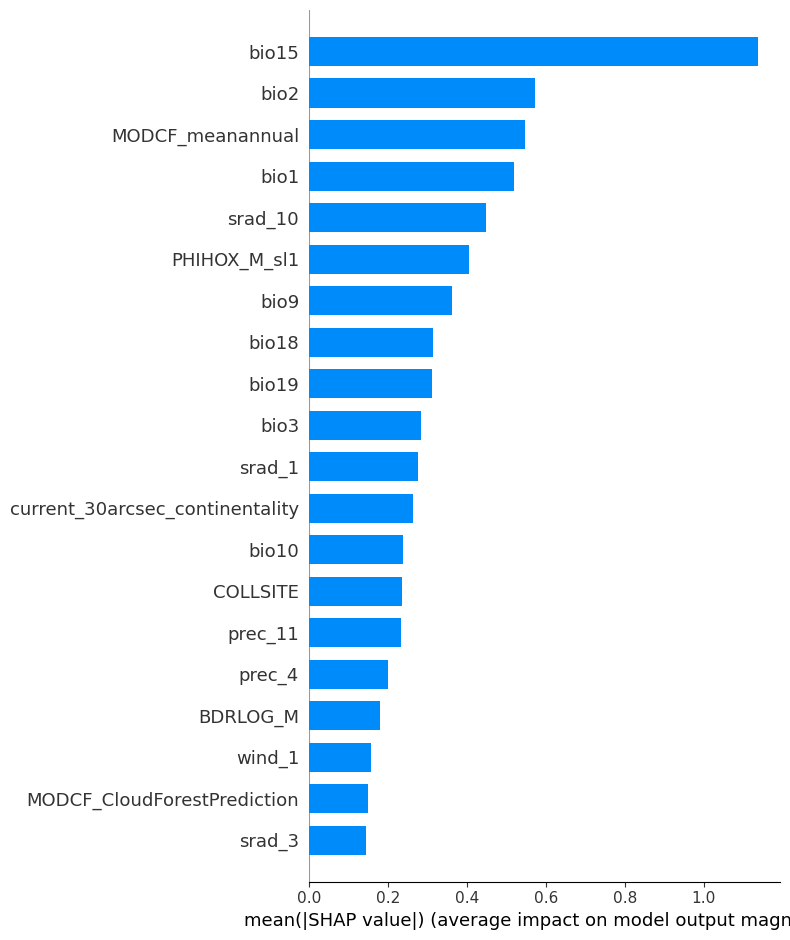

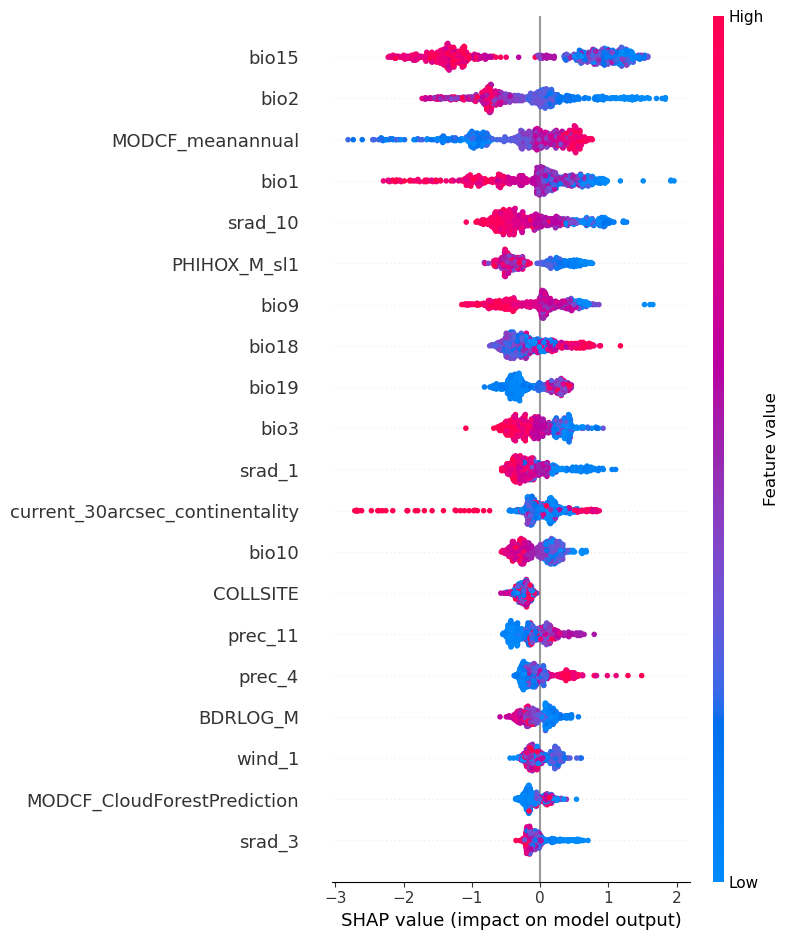

<Figure size 640x480 with 0 Axes>

In [82]:

import shap

# Explicador SHAP
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# --- 1. Importancia global ---
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

# --- 2. Impacto de cada variable ---
shap.summary_plot(shap_values, X_test, show=True)
plt.savefig("./graficas/shap_summary_sequia.png", dpi=300)

El ranking de barras muestra el impacto medio absoluto de cada variable, cuanto mayor es la barra, mayor influencia tiene la variable en la predicción de resistencia a sequía. El orden está normalizado, por lo que **bio15** es la variable más influyente del modelo. **bio15** mide cuánta variación existe en la precipitación mensual promedio a lo largo del año, es decir, la desviación estandar de la precipitación mensual dividida por el promedio anual, multiplicada por 100.

| Variable                 | Descripción                                      | Interpretación en el contexto de sequía                                                                                                 |
| ------------------------ | ------------------------------------------------ | --------------------------------------------------------------------------------------------------------------------------------------- |
| **bio15**                | *Precipitation seasonality (coef. de variación)* | Es la más determinante. Altos valores → ambientes con lluvias muy irregulares → favorecen accesiones adaptadas a estrés hídrico.        |
| **bio2**                 | *Mean diurnal range (max temp – min temp)*       | Representa la oscilación térmica diaria. Altas amplitudes suelen asociarse a estrés térmico y mayor adaptación fisiológica.             |
| **MODCF_meanannual**     | *Cobertura promedio de bosque nublado (MODCF)*   | Mide influencia de la nubosidad media anual. Baja cobertura puede relacionarse con zonas áridas → selección por tolerancia a radiación. |
| **bio1**                 | *Temperatura media anual*                        | Climas más cálidos pueden promover adaptaciones morfofisiológicas a la sequía.                                                          |
| **srad_10**              | *Radiación solar del décimo mes*                 | Afecta la evapotranspiración; sugiere importancia de la energía incidente en la adaptación.                                             |
| **PHIHOX_M_sl1**         | *pH del suelo (capa superficial)*                | Influye en la disponibilidad de nutrientes y estrés osmótico en raíces.                                                                 |
| **bio9 / bio18 / bio19** | *Temperaturas y precipitaciones estacionales*    | Indican que la variabilidad intraanual del clima tiene peso significativo.                                                              |


$$
BIO15 = 100 \times \frac{\text{Desviación estándar de la precipitación mensual}}{\text{Media de la precipitación mensual}}
$$

En la gráfica de dispersión SHAP, cada punto representa una accesión (una predicción). El eje X muestra el efecto SHAP, es decir,  si la variable aumenta o disminuye la probabilidad de resistencia.

El color indica el valor de la variable:

* **Rojo**  Alto valor
* **Azul**  Bajo valor

| Variable                              | Patrón SHAP observado          | Interpretación ecológica coherente                                                                                                              |
| ------------------------------------- | ------------------------------ | ----------------------------------------------------------------------------------------------------------------------------------------------- |
| **BIO15 (Precipitation seasonality)** | (valores altos) → izquierda | Accesiones de ambientes con lluvias muy irregulares tienden a **menor resistencia** (quizá estrés excesivo o suelos poco favorables).           |
| **BIO15 (Precipitation seasonality)** | (valores altos) → izquierda | Accesiones de ambientes con lluvias muy irregulares tienden a **menor resistencia** (quizá estrés excesivo o suelos poco favorables)     | → derecha                      | Accesiones de zonas con lluvias más regulares muestran **mayor resistencia** — posible adaptación fisiológica a disponibilidad estable de agua. |


El análisis SHAP permite identificar las variables climáticas y edáficas con mayor contribución al modelo XGBoost de predicción de resistencia a sequía.
La precipitaciones estacionales (BIO15) fue la variable con mayor influencia, seguida de la oscilación térmica diurna (BIO2), la cobertura media anual de nubes (MODCF_meanannual) y la temperatura media anual (BIO1).
Estas variables reflejan condiciones de alta variabilidad climática y radiación intensa, típicas de ambientes áridos o subhúmedos, lo que coincide con la adaptación esperada en accesiones resistentes a sequía.
El pH del suelo (PHIHOX_M_sl1) y la radiación solar mensual (srad_10) también mostraron una relación positiva con la resistencia, lo que sugiere que la adaptación al estrés hídrico no solo depende del clima sino también de la capacidad del suelo para sostener la fisiología vegetal bajo condiciones extremas.
En conjunto, los resultados SHAP confirman que el modelo XGBoost no solo predice con alta precisión, sino que además es interpretable y coherente con la ecología de la especie.

## **************************************************************************************************************************************************************


## Distribución de probabilidades ##
la distribución de probabilidades predichas por modelo (violin plot) es una de las formas más potentes de visualizar la calibración y discriminación probabilística de los modelos.

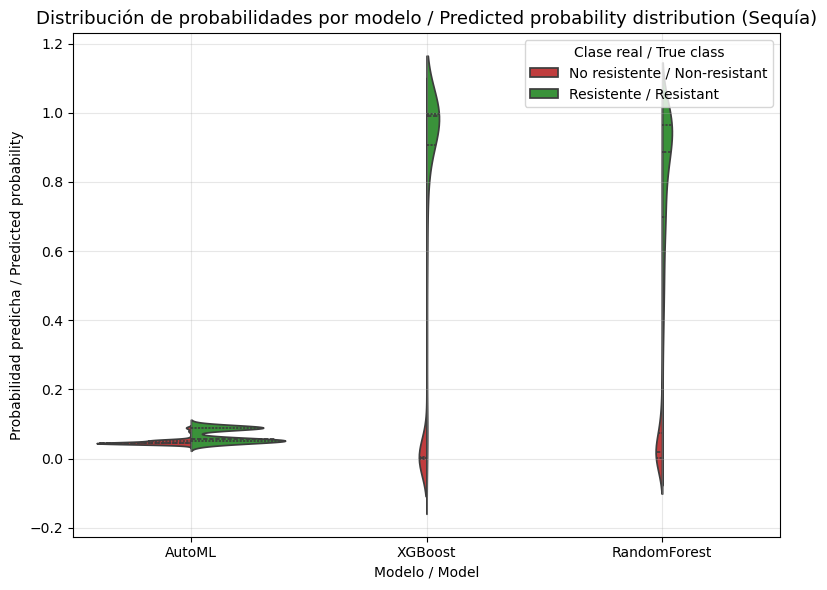

In [83]:
df_probs = resultados_sequia.copy()
df_probs["Clase_real"] = df_probs["y_true"].map({0: "No resistente / Non-resistant", 1: "Resistente / Resistant"})

plt.figure(figsize=(8,6))
sns.violinplot(
    data=df_probs,
    x="modelo",
    y="y_proba",
    hue="Clase_real",
    split=True,
    inner="quart",
    palette=["#d62728", "#2ca02c"]
)
plt.title("Distribución de probabilidades por modelo / Predicted probability distribution (Sequía)", fontsize=13)
plt.xlabel("Modelo / Model")
plt.ylabel("Probabilidad predicha / Predicted probability")
plt.legend(title="Clase real / True class")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./graficas/distribucion_sequia.png", dpi=300)
plt.show()


### Interpretación ###
El gráfico anteriro tipo violín (Violin Plot) permite mostrar la distribución de las probabilidades predichas por cada modelo.

* El color rojo representa las accesiones *no resistentes* a sequía **(0)**.
* EL color verde representa las accesiones *resistentes* a sequía **(1)**.

## AutoML ##

Tanto las clases rojas (0) como verdes (1) están concentradas entre 0.03 y 0.1, esto indica que no existe separación entre ambas clases, enotnces el modelo predice casi todas las accesiones con probabilidades bajas, sin distinguir resistentes de no resistentes.

AutoML no aprendió un patrón discriminante. Predice todo con una probabilidad casi constante, esto es un comportamiento típico de un modelo subentrenado o sobreajustado a la clase dominante.

## XGBoost ##

Distribución bimodal y separada, la clase roja (no resistente) está centrada cerca de **0.0** y **0.1** mientras la clase verde (resistente) está centrada cerca de **0.9** y **1.0**.

El solapamiento entre clases es mínimo.

El modelo asigna probabilidades altas a los resistentes y bajas a los no resistentes, mostrando una excelente discriminación probabilística.

el modelo tiene alta sensibilidad (recall) y alta precisión (precision), coherente con su AUC de 0.983.

## Random Forest ##

Comportamiento muy similar a XGBoost, aunque con un poco más de dispersión. Se puede observar una ligera mayor mezcla entre ambas clases en el rango **0.2** y **0.4**.

Random Forest distingue muy bien entre resistentes y no resistentes, pero con un pequeño grado de incertidumbre intermedia.
Esto puede deberse a su naturaleza de ensamble que hace que algunos árboles generan probabilidades medias, no tan extremas como XGBoost.

## Conclusión ##
El gráfico de distribución de probabilidades  muestra el grado de discriminación de los tres modelos frente a las clases reales de resistencia a sequía.

El modelo AutoML presenta una distribución muy estrecha en valores bajos (≈0.05), sin separación entre clases, lo que confirma su incapacidad para diferenciar accesiones resistentes. En contraste, los modelos XGBoost y Random Forest exhiben distribuciones claramente bimodales: las accesiones resistentes (verde) se concentran en probabilidades cercanas a 1.0, mientras que las no resistentes (rojo) se agrupan alrededor de 0.0.
Esta separación indica una alta capacidad de discriminación y buena calibración de probabilidades, coherente con los valores elevados de ROC-AUC (>0.97) y bajo Brier Score observados previamente.
En conjunto, ambos modelos de árboles muestran un comportamiento predictivo confiable, siendo XGBoost el de mejor discriminación.